# RamanBench — Benchmarking a New Model

This notebook shows how to evaluate a new model against the 28 precomputed baselines.

## Ecosystem

| Resource                       | Link                                                                                               |
|--------------------------------|----------------------------------------------------------------------------------------------------|
| **raman-data** (datasets)      | [GitHub](https://github.com/ml-lab-htw/raman_data) · [PyPI](https://pypi.org/project/raman-data/)  |
| **raman-bench** (this package) | [GitHub](https://github.com/ml-lab-htw/RamanBench) · [PyPI](https://pypi.org/project/raman-bench/) |
| **Live Leaderboard**           | [HuggingFace Space](https://huggingface.co/spaces/ml-lab-htw/RamanBench)                           |
| **Paper**                      | [arXiv TBD](https://arxiv.org/abs/TBD)                                                             |

In [1]:
# !pip install raman-bench raman-data scikit-learn

## Option A: Scikit-learn compatible model (simplest)

In [2]:
from raman_bench import Leaderboard
from sklearn.cross_decomposition import PLSRegression
from sklearn.ensemble import RandomForestClassifier

# Load precomputed baselines
lb = Leaderboard.from_precomputed()

print('Current #1 model:', lb.rank().iloc[0]['Model'])

Current #1 model: AutoGluon 1.5 (extreme, 4h)


In [3]:
results = lb.evaluate_and_add(
    model_name="PLS-2",
    model=PLSRegression(n_components=2),
    task="regression",
    seeds=3,
)
print(f"Evaluated on {len(results)} (dataset, seed) combinations")

2026-04-27 14:41:36,153 INFO raman_bench.benchmark:__init__:155: Datasets: 21 classification, 56 regression
Loading datasets: 100%|██████████| 21/21 [00:00<00:00, 14926.35it/s]
2026-04-27 14:41:41,618 INFO raman_bench.benchmark:__init__:155: Datasets: 21 classification, 56 regression
Loading datasets: 100%|██████████| 21/21 [00:00<00:00, 29136.75it/s]
2026-04-27 14:41:47,485 INFO raman_bench.benchmark:__init__:155: Datasets: 21 classification, 56 regression
Loading datasets: 100%|██████████| 21/21 [00:00<00:00, 5693.99it/s]
2026-04-27 14:41:53,121 INFO raman_bench.leaderboard:add_results:256: Added model 'PLS-2' to leaderboard.


Evaluated on 444 (dataset, seed) combinations


In [4]:
# View updated regression ranking
ranked = lb.rank(task="regression")
pls_row = ranked[ranked["Model"] == "PLS-2"]
pls_rank = pls_row.index[0] + 1
print(f"PLS-2 ranked #{pls_rank} out of {len(ranked)} models (regression)")
ranked.head(10)


PLS-2 ranked #17 out of 28 models (regression)


,Rank,model_id,Model,Category,Elo,Score,Avg Rank,Improvability,Train Time s,Infer. s/1K
0,1,AUTOGLUON,"AutoGluon 1.5 (extreme, 4h)",AutoML,1558.0,0.7944,3.8,20.6,1776.3,220.7
1,2,REALTABPFN-V2.5,TabPFN v2.5,Tabular Foundation,1529.0,0.7629,4.0,23.7,89.6,100.8
2,3,REALTABPFN-V2,TabPFN v2,Tabular Foundation,1402.0,0.6717,5.8,32.8,77.6,146.4
3,4,TABICL,TabICL,Tabular Foundation,1443.0,0.6391,5.5,36.1,39.9,130.3
4,5,MITRA,MITRA,Tabular Foundation,1312.0,0.5123,7.4,48.8,827.4,626.5
5,6,TABDPT,TabDPT,Tabular Foundation,1136.0,0.2945,11.9,70.6,12.3,80.2
6,7,REZERONET,ReZeroNet,Raman-Specific,1133.0,0.2617,12.8,73.8,44.6,23.1
7,8,PLS,PLS,Traditional ML,1004.0,0.2252,15.1,77.5,29.7,19.2
8,9,REALMLP,RealMLP,Deep Learning,1111.0,0.2250,13.0,77.5,1935.5,71.1
9,10,LR,Logistic Reg.,Traditional ML,1002.0,0.2140,15.6,78.6,37.2,41.2


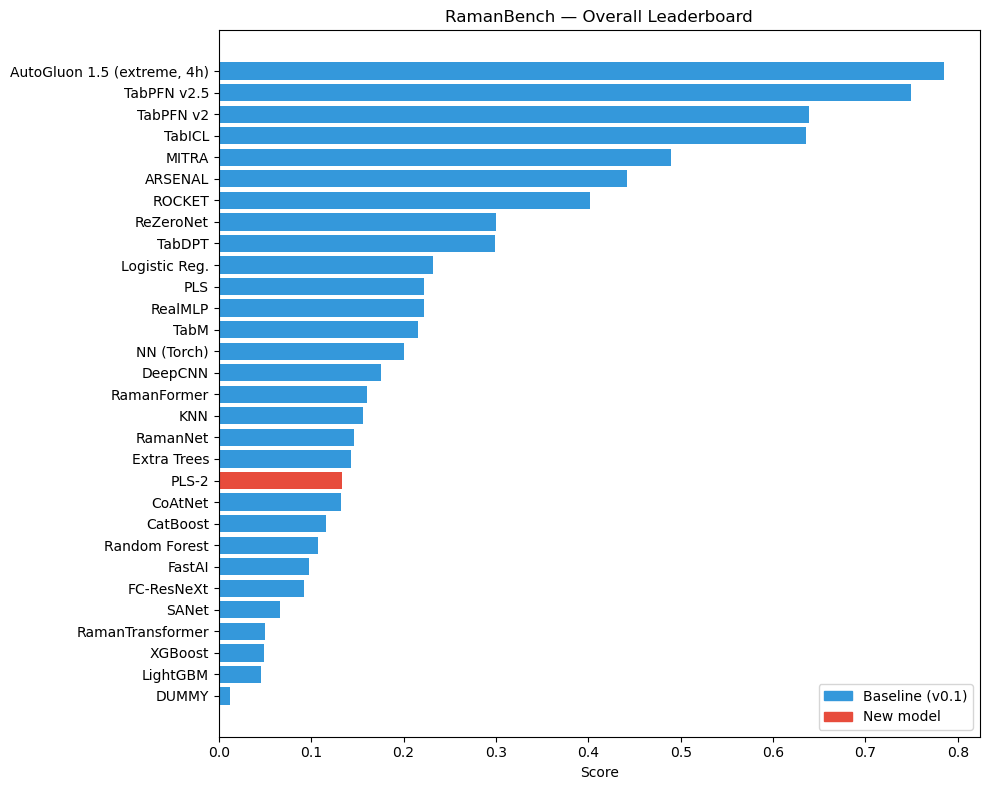

In [5]:
import matplotlib.pyplot as plt

fig = lb.plot(task='overall', n_top=35)
plt.show()

## Option B: Adding results from a pre-existing run

If you have already run your model and computed metrics, you can add the results directly:

In [7]:
import pandas as pd
from raman_bench import Leaderboard

# Your pre-computed metrics DataFrame
# Must have columns: seed, key, and metric columns (rmse/r2 for regression, f1_score for classification)
my_metrics = pd.DataFrame({
    'seed': [0, 1, 2],
    'key': ['amino_acids_glycine_0', 'amino_acids_glycine_0', 'amino_acids_glycine_0'],
    'rmse': [0.05, 0.048, 0.052],
    'r2': [0.95, 0.96, 0.94],
})

lb = Leaderboard.from_precomputed()
lb.add_results('My Existing Model', my_metrics)
print(lb.rank().tail(5))

2026-04-27 14:42:16,419 INFO raman_bench.leaderboard:from_precomputed:136: Loaded precomputed leaderboard: 10449 regression rows, 1827 classification rows
2026-04-27 14:42:16,496 INFO raman_bench.leaderboard:add_results:256: Added model 'My Existing Model' to leaderboard.


    Rank          model_id             Model           Category    Elo  \
25    26             SANET             SANet     Raman-Specific  798.0   
26    27  RAMANTRANSFORMER  RamanTransformer     Raman-Specific  710.0   
27    28               XGB           XGBoost  Gradient Boosting  923.0   
28    29               GBM          LightGBM  Gradient Boosting  950.0   
29    30             DUMMY             DUMMY                NaN    NaN   

     Score  Avg Rank  Improvability  Train Time s  Infer. s/1K  
25  0.0670      21.0           93.3          37.9         39.7  
26  0.0494      22.6           95.1         429.8        134.8  
27  0.0457      18.0           95.4          57.9          3.7  
28  0.0432      17.0           95.7        1453.5          7.3  
29  0.0119      23.2           98.8           NaN          NaN  


## Option C: Full benchmark run via AutoGluon

For AutoGluon-integrated models, use the CLI:

```bash
# Run a specific model
raman-bench run --config configs/benchmark_v0.1.json --model MYMODEL

# Then load results and compare
```

See [CONTRIBUTING.md](../CONTRIBUTING.md) for instructions on implementing a fully
integrated AutoGluon model.